# Tiny Dreamer Highway — Colab Baseline Real Run

**Name:** Esteban  
**Course:** CSC 580 AI 2  
**Assignment:** Final Project — Dream the Road  
**AI tools consulted:** GitHub Copilot

Use this notebook for the first real baseline run before any non-trivial optimization changes.

## Baseline intent

This notebook should be your comparison point for later optimization work. Keep the seed, runtime type, and run length stable when comparing results.

In [1]:
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')
REPO_URL = 'https://github.com/estmon8u/CSC_580_Final_Project.git'
DRIVE_ROOT = Path('/content/drive/MyDrive/CSC_580_Final_Project')
ARTIFACT_ROOT = DRIVE_ROOT / 'artifacts'

for path in [DRIVE_ROOT, ARTIFACT_ROOT, ARTIFACT_ROOT / 'training_runs']:
    path.mkdir(parents=True, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%%bash
set -e
REPO_URL='https://github.com/estmon8u/CSC_580_Final_Project.git'
if [ ! -d /content/CSC_580_Final_Project/.git ]; then
  git clone "${REPO_URL}" /content/CSC_580_Final_Project
else
  cd /content/CSC_580_Final_Project
  git pull --ff-only origin main
fi
cd /content/CSC_580_Final_Project
python -m pip install --upgrade pip --quiet
python -m pip install -e . --quiet

Already up to date.


From https://github.com/estmon8u/CSC_580_Final_Project
 * branch            main       -> FETCH_HEAD


In [3]:
import json
import sys
import torch
from pathlib import Path

PROJECT_ROOT = Path('/content/CSC_580_Final_Project')
if str(PROJECT_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from tiny_dreamer_highway.config import load_experiment_config
from tiny_dreamer_highway.training import run_training_experiment

CONFIG_PATH = PROJECT_ROOT / 'examples' / 'training_run.yaml'
config = load_experiment_config(CONFIG_PATH)
print('Loaded config from:', CONFIG_PATH)
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'none')
print('Batch size:', config.training.batch_size)
print('World-model updates/cycle:', config.training.world_model_updates_per_cycle)
print('Behavior updates/cycle:', config.training.behavior_updates_per_cycle)

Loaded config from: /content/CSC_580_Final_Project/examples/training_run.yaml
GPU: NVIDIA H100 80GB HBM3
Batch size: 32
World-model updates/cycle: 2
Behavior updates/cycle: 2


In [4]:
RUN_NAME = 'baseline_real_run_001'
RUN_ARTIFACT_ROOT = ARTIFACT_ROOT / 'training_runs' / RUN_NAME
RUN_ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)

CYCLES = None
WARM_START_STEPS = None
POLICY_STEPS = None
CHECKPOINT_INTERVAL = None
RESUME_FROM = None

print('Run name:', RUN_NAME)
print('Effective cycles:', config.training.cycles if CYCLES is None else CYCLES)

Run name: baseline_real_run_001
Effective cycles: 500


In [5]:
print('Launching baseline real run. Per-cycle progress lines will appear below.')

training_summary = run_training_experiment(
    config,
    RUN_ARTIFACT_ROOT,
    cycles=CYCLES,
    warm_start_steps=WARM_START_STEPS,
    policy_steps=POLICY_STEPS,
    checkpoint_interval=CHECKPOINT_INTERVAL,
    resume_from=RESUME_FROM,
)

print('Completed cycles:', training_summary.completed_cycles)
print('Latest checkpoint:', training_summary.latest_checkpoint)
print('Latest metrics:', training_summary.latest_record)

Launching baseline real run. Per-cycle progress lines will appear below.
[train] starting run | cycles=500 | start_step=1 | warm_start_steps=1000 | policy_steps=32 | device=cuda
[train] step=1/500 | warm=1000 | policy=32 | replay=1032 | world_total=3.2649 | actor=0.0094 | critic=0.0422 | cycle_s=222.8 | elapsed_s=222.8 | checkpoint=-
[train] step=2/500 | warm=0 | policy=32 | replay=1064 | world_total=3.1829 | actor=-0.2180 | critic=0.0676 | cycle_s=6.9 | elapsed_s=229.6 | checkpoint=-
[train] step=3/500 | warm=0 | policy=32 | replay=1096 | world_total=3.2110 | actor=-0.4963 | critic=0.2143 | cycle_s=7.0 | elapsed_s=236.7 | checkpoint=-
[train] step=4/500 | warm=0 | policy=32 | replay=1128 | world_total=4.1072 | actor=-0.5614 | critic=0.3212 | cycle_s=7.1 | elapsed_s=243.8 | checkpoint=-
[train] step=5/500 | warm=0 | policy=32 | replay=1160 | world_total=3.1874 | actor=-0.6046 | critic=0.3451 | cycle_s=7.0 | elapsed_s=250.8 | checkpoint=-
[train] step=6/500 | warm=0 | policy=32 | replay

In [6]:
summary_path = training_summary.log_dir / 'latest_summary.json'
summary_payload = json.loads(summary_path.read_text(encoding='utf-8'))
summary_payload

{'checkpoint_file': '/content/drive/MyDrive/CSC_580_Final_Project/artifacts/training_runs/baseline_real_run_001/checkpoints/checkpoint_00500.pt',
 'latest_metrics': {'behavior/actor_loss': -9.700623989105225,
  'behavior/critic_loss': 0.9545129835605621,
  'behavior/imagined_reward_mean': 0.11113570630550385,
  'behavior/imagined_value_mean': 9.196489334106445,
  'policy_added': 32,
  'replay_size': 17000,
  'step': 500,
  'warm_start_added': 0,
  'world_model/kl_loss': 3.0,
  'world_model/kl_loss_raw': 0.5145090520381927,
  'world_model/reconstruction_loss': 0.013492194004356861,
  'world_model/reward_loss': 0.07164616137742996,
  'world_model/total_loss': 3.0851383209228516},
 'latest_step': 500}

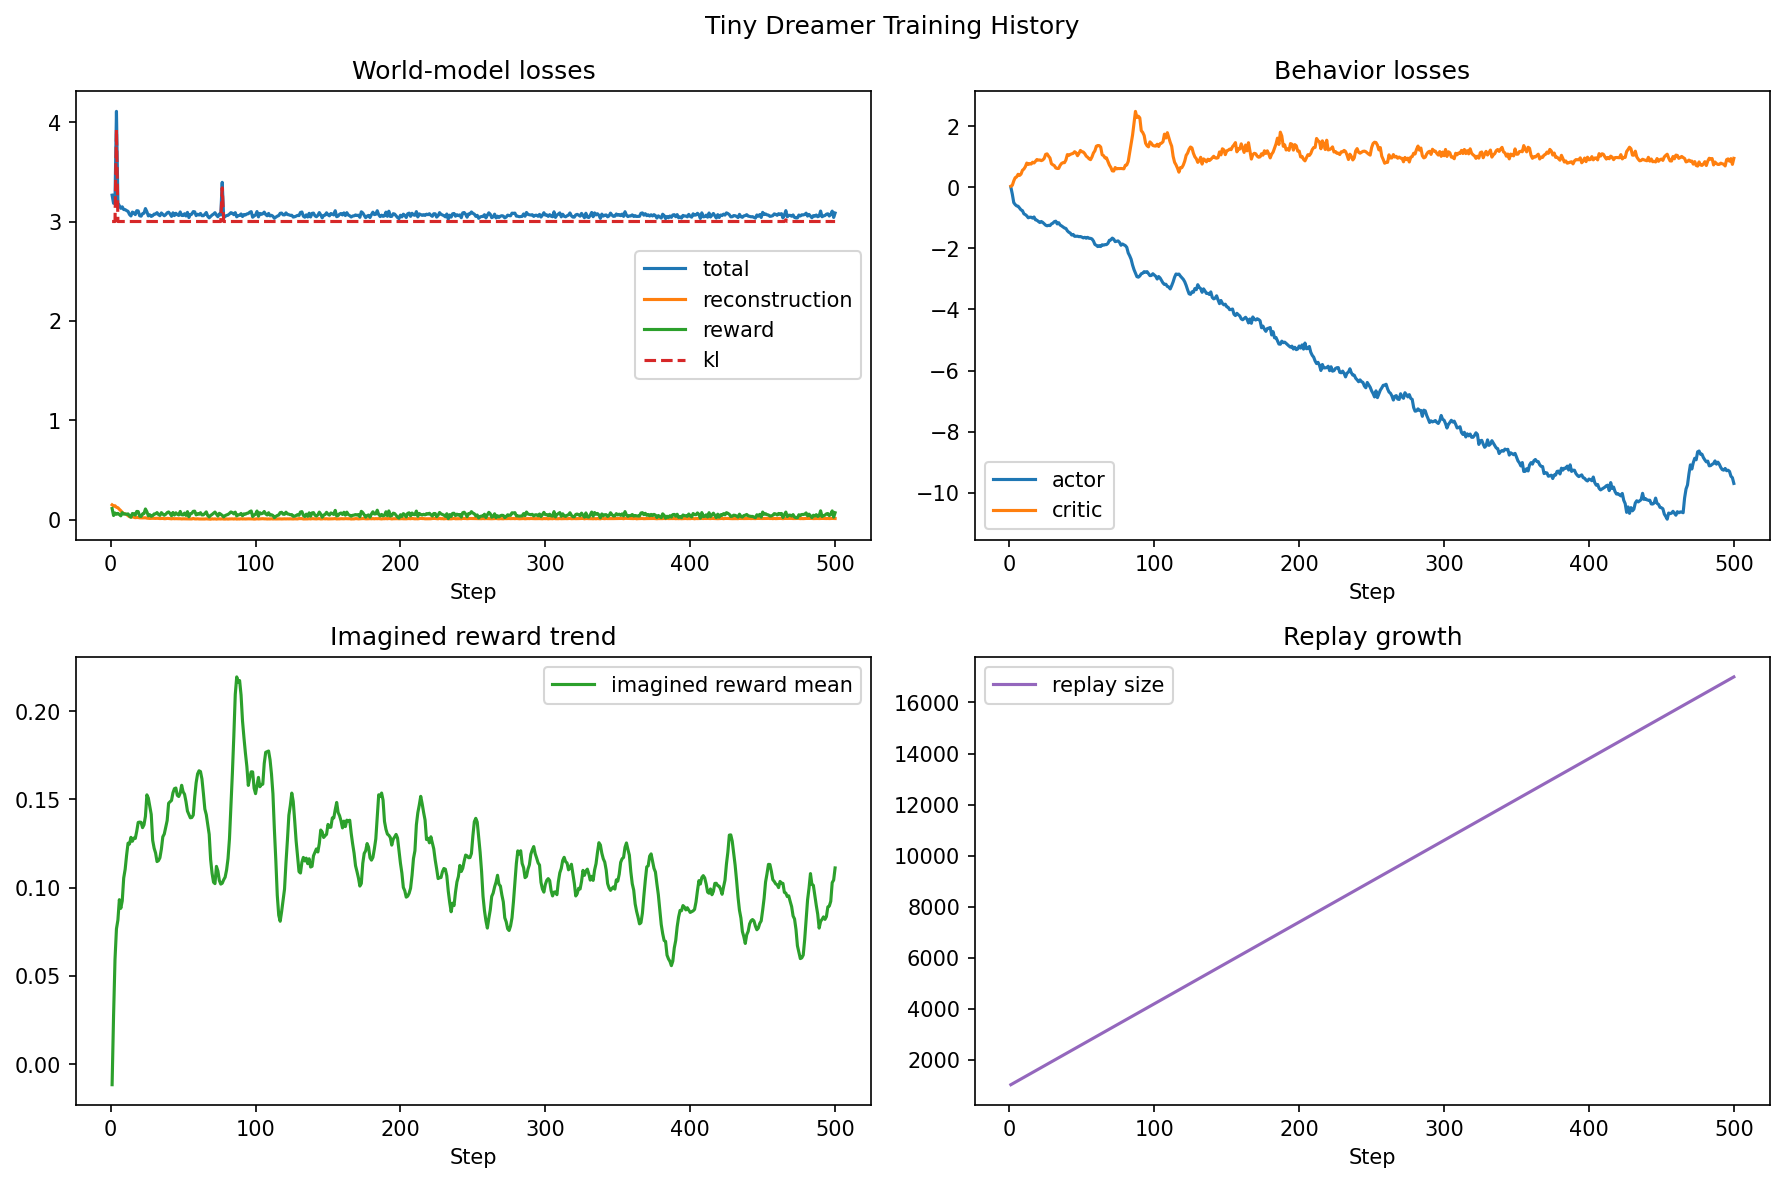

{'best_imagined_reward_mean': 0.2193620651960373,
 'best_imagined_reward_step': 87,
 'best_world_model_step': 233,
 'best_world_model_total_loss': 3.022945523262024,
 'largest_replay_size': 17000,
 'largest_replay_step': 500,
 'last_metrics': {'behavior/actor_loss': -9.700623989105225,
  'behavior/critic_loss': 0.9545129835605621,
  'behavior/imagined_reward_mean': 0.11113570630550385,
  'behavior/imagined_value_mean': 9.196489334106445,
  'policy_added': 32,
  'replay_size': 17000,
  'step': 500,
  'warm_start_added': 0,
  'world_model/kl_loss': 3.0,
  'world_model/kl_loss_raw': 0.5145090520381927,
  'world_model/reconstruction_loss': 0.013492194004356861,
  'world_model/reward_loss': 0.07164616137742996,
  'world_model/total_loss': 3.0851383209228516},
 'last_step': 500,
 'num_records': 500}

In [7]:
from IPython.display import Image, display
from tiny_dreamer_highway.evaluation import export_training_history_artifacts

analysis_outputs = export_training_history_artifacts(
    training_summary.log_dir / 'cycle_metrics.csv',
    RUN_ARTIFACT_ROOT / 'analysis',
    prefix=RUN_NAME,
)

display(Image(filename=str(analysis_outputs['curves'])))
json.loads(analysis_outputs['summary'].read_text(encoding='utf-8'))

## Agent Driving Demo

Record agent-driving GIFs using the trained policy from this run. These show the actor driving in the real highway-env.

Using demo recorder from: tiny_dreamer_highway.evaluation.policy_rollout
[demo] episode 1/3 | steps=40 | reward=12.09 | OK | saved baseline_real_run_001_ep01.gif
[demo] episode 2/3 | steps=40 | reward=0.00 | OK | saved baseline_real_run_001_ep02.gif
[demo] episode 3/3 | steps=40 | reward=0.00 | OK | saved baseline_real_run_001_ep03.gif
[demo] done | avg_reward=4.03 | summary=baseline_real_run_001_summary.json

baseline_real_run_001_ep01.gif


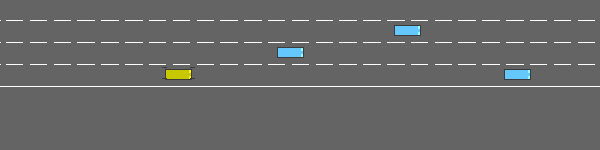


baseline_real_run_001_ep02.gif


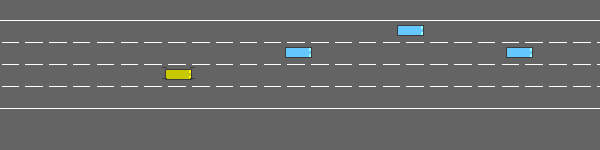


baseline_real_run_001_ep03.gif


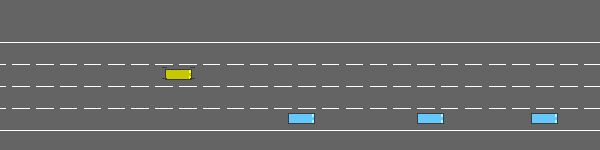

In [8]:
from IPython.display import Image, display
import importlib
import tiny_dreamer_highway.evaluation as evaluation_pkg

try:
    evaluation_pkg = importlib.reload(evaluation_pkg)
    record_demo_videos = evaluation_pkg.record_demo_videos
except (AttributeError, ImportError):
    from tiny_dreamer_highway.evaluation.policy_rollout import record_demo_videos

print('Using demo recorder from:', record_demo_videos.__module__)

demo_outputs = record_demo_videos(
    config,
    checkpoint_path=training_summary.latest_checkpoint,
    output_dir=RUN_ARTIFACT_ROOT / 'demo_videos',
    num_episodes=3,
    max_steps=200,
    fps=15,
    seed=config.seed,
    prefix=RUN_NAME,
    device=config.device,
)

for gif_path in demo_outputs.video_paths:
    print(f'\n{gif_path.name}')
    display(Image(filename=str(gif_path)))